<a href="https://colab.research.google.com/github/AnthonyMath1022/AnthonyMath1022/blob/main/Retail_Analysis_Nlinear.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
from IPython.display import display
from google.colab import drive
drive.mount('/content/drive')
%load_ext cudf.pandas
print('Loading data...')
train_path = '/content/drive/MyDrive/Reatilforecast/src/train.csv'
train_df = pd.read_csv(train_path, low_memory=True)
train_df['date'] = pd.to_datetime(train_df['date'])
pd.set_option('display.max_columns', 10)
display(train_df)


Mounted at /content/drive
Loading data...


/tmp/ipykernel_4786/2450478014.py:9: DtypeWarning: Columns (5) have mixed types. Specify dtype option on import or set low_memory=False.
  train_df = pd.read_csv(train_path, low_memory=True)


,id,date,store_nbr,item_nbr,unit_sales,onpromotion
0,0,2013-01-01,25,103665,7.0,NaN
1,1,2013-01-01,25,105574,1.0,NaN
2,2,2013-01-01,25,105575,2.0,NaN
3,3,2013-01-01,25,108079,1.0,NaN
4,4,2013-01-01,25,108701,1.0,NaN
...,...,...,...,...,...,...
125497035,125497035,2017-08-15,54,2089339,4.0,False
125497036,125497036,2017-08-15,54,2106464,1.0,True
125497037,125497037,2017-08-15,54,2110456,192.0,False
125497038,125497038,2017-08-15,54,2113914,198.0,True


In [2]:
start_date = '2017-07-01'
end_date = '2017-12-31'

train_df = train_df[(train_df['date'] >= start_date) & (train_df['date'] <= end_date)]
pd.set_option('display.max_columns', 10)
display(train_df)
train_df.count()
train_df.isna().sum()


,id,date,store_nbr,item_nbr,unit_sales,onpromotion
120642911,120642911,2017-07-01,1,99197,2.0,False
120642912,120642912,2017-07-01,1,103520,2.0,False
120642913,120642913,2017-07-01,1,103665,11.0,False
120642914,120642914,2017-07-01,1,105574,2.0,False
120642915,120642915,2017-07-01,1,105575,3.0,False
...,...,...,...,...,...,...
125497035,125497035,2017-08-15,54,2089339,4.0,False
125497036,125497036,2017-08-15,54,2106464,1.0,True
125497037,125497037,2017-08-15,54,2110456,192.0,False
125497038,125497038,2017-08-15,54,2113914,198.0,True


,0
id,0
date,0
store_nbr,0
item_nbr,0
unit_sales,0
onpromotion,0


In [3]:
import pandas as pd

item_path = '/content/drive/MyDrive/Reatilforecast/src/items.csv'
store_path = '/content/drive/MyDrive/Reatilforecast/src/stores.csv'
oil_path = '/content/drive/MyDrive/Reatilforecast/src/oil.csv'

item = pd.read_csv(item_path)
store = pd.read_csv(store_path)
oil = pd.read_csv(oil_path )
oil = oil[(oil['date'] >= start_date) & (oil['date'] <= end_date)]

train_df = pd.merge(train_df,item,on='item_nbr',how='left')
train_df = pd.merge(train_df,store,on='store_nbr',how='left')
train_df.isna().sum()

id             0
date           0
store_nbr      0
item_nbr       0
unit_sales     0
onpromotion    0
family         0
class          0
perishable     0
city           0
state          0
type           0
cluster        0
dtype: int64

In [4]:
import numpy as np

def most_frequent_sales(data, variable, N, all='TRUE'):


    # counts
    values, counts = np.unique(data[variable].to_numpy(), return_counts=True)

    # Ensure values and counts are 2D column vectors before stacking
    values_2d = values.reshape(-1, 1)
    counts_2d = counts.reshape(-1, 1)

    # Nx2 table: [value, count]
    labels_freq_pd = np.column_stack((values_2d, counts_2d))

    # sort by count desc
    labels_freq_pd = labels_freq_pd[np.argsort(labels_freq_pd[:, 1])[::-1]]

    # keep top N
    topN = labels_freq_pd[:N]
    main_labels = topN[:, 0] if all == 'False' else labels_freq_pd[:, 0]

    # raw labels (replace deprecated as_matrix)
    labels_raw_np = data[variable].to_numpy().reshape(-1, 1)

    # indices where label in main_labels (same style as your labels_filtered_index[0])
    labels_filtered_index = np.where(np.isin(labels_raw_np.ravel(), main_labels))

    return topN, labels_filtered_index

label_freq, labels_filtered_index = most_frequent_sales(train_df, 'item_nbr', 5, 'FALSE')
print("pd_train.shape=", labels_filtered_index[0].shape)

pd_train_filtered = train_df.loc[labels_filtered_index[0], :]
print("pd_train_filtered.shape = ", pd_train_filtered.shape)


pd_train.shape= (4854129,)
pd_train_filtered.shape =  (4854129, 13)


In [5]:
pd_train_filtered  = pd_train_filtered.drop(['city','state','type','cluster','store_nbr','item_nbr','family','class','id'], axis = 1)

In [6]:

dummy_variables = ['onpromotion','perishable']

for var in dummy_variables:
    dummy = pd.get_dummies(pd_train_filtered [var], prefix = var, drop_first = False).astype(int)
    pd_train_filtered  = pd.concat([pd_train_filtered ,dummy], axis = 1)

pd_train_filtered  = pd_train_filtered.drop(dummy_variables, axis = 1)


In [7]:
import pandas as pd

# 1. Ensure your date columns are actual datetime objects
pd_train_filtered ['date'] = pd.to_datetime(pd_train_filtered ['date'])
oil['date'] = pd.to_datetime(oil['date'])

# 2. Generate the complete date range automatically
# pd.date_range replaces the manual loop and delta calculation
calendar = pd.DataFrame({
    'date': pd.date_range(start=train_df.date.min(), end=train_df.date.max())
})

# 3. Merge
oil = calendar.merge(oil, on='date', how='left')

In [8]:
na_index_oil = oil[oil['dcoilwtico'].isnull() == True].index.values

#Define the index to use to apply the formala
na_index_oil_plus = na_index_oil.copy()
na_index_oil_minus = np.maximum(0, na_index_oil-1)

for i in range(len(na_index_oil)):
    k = 1
    while (na_index_oil[min(i+k,len(na_index_oil)-1)] == na_index_oil[i]+k):
        k += 1
    na_index_oil_plus[i] = min(len(oil)-1, na_index_oil_plus[i] + k )

#Apply the formula
for i in range(len(na_index_oil)):
    if (na_index_oil[i] == 0):
        oil.loc[na_index_oil[i], 'dcoilwtico'] = oil.loc[na_index_oil_plus[i], 'dcoilwtico']
    elif (na_index_oil[i] == len(oil)):
        oil.loc[na_index_oil[i], 'dcoilwtico'] = oil.loc[na_index_oil_minus[i], 'dcoilwtico']
    else:
        oil.loc[na_index_oil[i], 'dcoilwtico'] = (oil.loc[na_index_oil_plus[i], 'dcoilwtico'] + oil.loc[na_index_oil_minus[i], 'dcoilwtico'])/ 2

pd_train_filtered  = pd_train_filtered.merge(oil, left_on='date', right_on='date', how='left')


In [9]:
pd_train_filtered.sample(10)

,date,unit_sales,onpromotion_False,onpromotion_True,perishable_0,perishable_1,dcoilwtico
1034078,2017-07-10,3.34,1,0,0,1,44.400
1395883,2017-07-14,9.00,1,0,1,0,46.530
4048466,2017-08-08,4.00,1,0,1,0,49.070
3294693,2017-08-01,19.00,1,0,0,1,49.190
3698895,2017-08-04,14.00,1,0,1,0,49.570
1188556,2017-07-11,1.00,1,0,0,1,45.060
1966333,2017-07-19,1.00,1,0,1,0,47.100
250387,2017-07-03,3.00,1,0,1,0,45.110
3028024,2017-07-29,1.00,0,1,1,0,49.965
1783164,2017-07-17,3.00,1,0,1,0,46.020


In [10]:
pd_train_filtered.count()

date                 4854129
unit_sales           4854129
onpromotion_False    4854129
onpromotion_True     4854129
perishable_0         4854129
perishable_1         4854129
dcoilwtico           4854129
dtype: int64

In [11]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

# --- CONFIGURATION ---
LOOKBACK = 7
HORIZON = 1
TOP_N = 10

# 1. Filter for Top 10 Items
# We use a wider date range (from Jan 2017) to ensure enough data for lookback and splitting.
local_start_date = '2017-01-01'

temp_base_df = pd.read_csv(train_path, low_memory=True)
temp_base_df['date'] = pd.to_datetime(temp_base_df['date'])
temp_base_df = temp_base_df[(temp_base_df['date'] >= local_start_date) & (temp_base_df['date'] <= end_date)].copy()

# Re-merge with item and store data
temp_item_df = pd.read_csv(item_path)
temp_store_df = pd.read_csv(store_path)
temp_base_df = pd.merge(temp_base_df, temp_item_df, on='item_nbr', how='left')
temp_base_df = pd.merge(temp_base_df, temp_store_df, on='store_nbr', how='left')

# Reload and merge Oil data (full range to cover Jan-July)
oil_full = pd.read_csv(oil_path)
oil_full['date'] = pd.to_datetime(oil_full['date'])
temp_base_df = pd.merge(temp_base_df, oil_full[['date', 'dcoilwtico']], on='date', how='left')

# Top 10 items
top_items = temp_base_df['item_nbr'].value_counts().head(TOP_N).index
pd_train_filtered = temp_base_df[temp_base_df['item_nbr'].isin(top_items)].copy()

# 2. Pivot the Data to Wide Format
# Sales Pivot
pivoted_sales = pd_train_filtered.pivot_table(
    index='date',
    columns='item_nbr',
    values='unit_sales',
    fill_value=0
)
pivoted_sales.columns = [f'sales_{i}' for i in pivoted_sales.columns]

# Promotion Pivot
if 'onpromotion' in pd_train_filtered.columns:
    pd_train_filtered['onpromotion'] = pd_train_filtered['onpromotion'].astype(int)
    pivoted_promo = pd_train_filtered.pivot_table(
        index='date',
        columns='item_nbr',
        values='onpromotion',
        fill_value=0
    )
    pivoted_promo.columns = [f'promo_{i}' for i in pivoted_promo.columns]
else:
    pivoted_promo = pd.DataFrame()

# Oil Data (Common Feature)
oil_series = pd_train_filtered.groupby('date')['dcoilwtico'].max()

# 3. Combine into one Wide Dataframe
combined = pd.concat([pivoted_sales, pivoted_promo, oil_series], axis=1)

# Fill gaps
combined = combined.ffill().bfill()

# Define targets and features
stock_cols = pivoted_sales.columns.tolist()
print(f"Target Columns ({len(stock_cols)}): {stock_cols}")
print(f"Total Features: {combined.shape[1]}")
print(f"Total Data Points (Days): {len(combined)}")

# --- TRAIN/TEST SPLIT ---
# Adjusted test_len to 16 days (typical for this dataset's horizon)
test_len = 30
trainval = combined.iloc[:-test_len]
test_data = combined.iloc[-test_len:]

val_len = int(len(trainval) * 0.15)
train_len = len(trainval) - val_len

train_data = trainval.iloc[:train_len]
val_data = trainval.iloc[train_len:]

print(f"Train size: {len(train_data)}, Val size: {len(val_data)}, Test size: {len(test_data)}")

# Scaling
feat_scaler = MinMaxScaler()
feat_scaler.fit(train_data.values)

train_scaled = feat_scaler.transform(train_data.values)
val_scaled = feat_scaler.transform(val_data.values)
test_scaled = feat_scaler.transform(test_data.values)

/usr/local/lib/python3.12/dist-packages/cudf/pandas/fast_slow_proxy.py:30: DtypeWarning: Columns (5) have mixed types. Specify dtype option on import or set low_memory=False.
  return fn(*args, **kwargs)


Target Columns (10): ['sales_222879', 'sales_261052', 'sales_265559', 'sales_314384', 'sales_323013', 'sales_364606', 'sales_502331', 'sales_1052563', 'sales_1157564', 'sales_1162382']
Total Features: 21
Total Data Points (Days): 227
Train size: 168, Val size: 29, Test size: 30


In [12]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np

class Model(nn.Module):
    """
    Normalization-Linear
    """
    def __init__(self, configs):
        super(Model, self).__init__()
        self.seq_len = configs.seq_len
        self.pred_len = configs.pred_len

        # Use this line if you want to visualize the weights
        # self.Linear.weight = nn.Parameter((1/self.seq_len)*torch.ones([self.pred_len,self.seq_len]))
        self.channels = configs.enc_in
        self.individual = configs.individual
        if self.individual:
            self.Linear = nn.ModuleList()
            for i in range(self.channels):
                self.Linear.append(nn.Linear(self.seq_len,self.pred_len))
        else:
            self.Linear = nn.Linear(self.seq_len, self.pred_len)

    def forward(self, x):
        # x: [Batch, Input length, Channel]
        seq_last = x[:,-1:,:].detach()
        x = x - seq_last
        if self.individual:
            output = torch.zeros([x.size(0),self.pred_len,x.size(2)],dtype=x.dtype).to(x.device)
            for i in range(self.channels):
                output[:,:,i] = self.Linear[i](x[:,:,i])
            x = output
        else:
            x = self.Linear(x.permute(0,2,1)).permute(0,2,1)
        x = x + seq_last
        return x # [Batch, Output length, Channel]

In [13]:
import torch
from torch.utils.data import Dataset, DataLoader


class TimeSeriesDataset(Dataset):
    def __init__(self, data, seq_length, pred_length=1):
        """
        data: numpy array of shape (n_samples, n_features)
        seq_length: length of input sequence (lookback window)
        pred_length: length of prediction horizon
        """
        self.data = torch.FloatTensor(data)
        self.seq_length = seq_length
        self.pred_length = pred_length

    def __len__(self):
        return len(self.data) - self.seq_length - self.pred_length + 1

    def __getitem__(self, idx):
        # Input sequence (x): from idx to idx+seq_length
        x = self.data[idx:idx+self.seq_length, :]

        # Target (y): the next 'pred_length' values (all columns)
        y = self.data[idx+self.seq_length:idx+self.seq_length+self.pred_length, :]

        return x, y

In [14]:
from types import SimpleNamespace
import torch
from sklearn import metrics

configs = SimpleNamespace(
    seq_len=14,
    pred_len=7,
    enc_in=len(stock_cols),   # IMPORTANT: number of assets
    individual=False
)

train_dataset = TimeSeriesDataset(train_scaled, configs.seq_len, configs.pred_len)

val_dataset = TimeSeriesDataset(val_scaled, configs.seq_len, configs.pred_len)

test_dataset = TimeSeriesDataset(test_scaled, configs.seq_len, configs.pred_len)



train_loader = DataLoader(train_dataset, batch_size=64, shuffle=False)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

model = Model(configs)
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)
criterion = torch.nn.MSELoss()

# 2. OPTIMIZATION: Add Early Stopping Logic
best_val_loss = float('inf')
patience = 20
trigger_times = 0

train_epoch_losses = []
test_losses = []
val_epoch_losses = []

print("Starting Training...")
print("Starting Training...")
for epoch in range(500): # Max epochs
    # --- TRAIN ---
    model.train()
    train_loss = 0.0

    # Remove these lines - they're not needed for training
    # epoch_actuals = []
    # epoch_preds = []

    for x, y in train_loader:
        x, y = x.float(), y.float()

        optimizer.zero_grad()
        pred = model(x)
        loss = criterion(pred, y)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * x.size(0)

    train_loss /= len(train_loader.dataset)
    train_epoch_losses.append(train_loss)

    # --- VAL ---
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for x, y in val_loader:
            x, y = x.float(), y.float()
            pred = model(x)
            loss = criterion(pred, y)
            val_loss += loss.item() * x.size(0)
    val_loss /= len(val_loader.dataset)
    val_epoch_losses.append(val_loss)

    if epoch % 10 == 0:
        print(f"Epoch {epoch}: Train Loss = {train_loss:.6f}, Val Loss = {val_loss:.6f}")

    # --- EARLY STOPPING ---
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        trigger_times = 0
        torch.save(model.state_dict(), 'best_model.pth')
    else:
        trigger_times += 1
        if trigger_times >= patience:
            print(f"Early stopping at epoch {epoch}")
            break

# 4. FINAL EVALUATION: Load best model and Inverse Transform
model.load_state_dict(torch.load('best_model.pth'))
model.eval()
# After getting predictions

# After getting predictions
final_train_actuals = []
final_train_preds = []

with torch.no_grad():
    for x, y in train_loader:
        x, y = x.float(), y.float()
        pred = model(x)
        final_train_actuals.append(y.cpu().numpy())
        final_train_preds.append(pred.cpu().numpy())

train_actuals = np.concatenate(final_train_actuals, axis=0)
train_predictions = np.concatenate(final_train_preds, axis=0)

# Debug: Check shapes before reshaping
print(f"train_predictions shape: {train_predictions.shape}")
print(f"train_actuals shape: {train_actuals.shape}")

# Reshape for inverse_transform to (num_total_predictions, num_features)
# Current shape is (num_samples_from_dataloader, pred_len, num_features)
# So, flatten the first two dimensions
num_samples_from_dataloader, pred_len, num_features = train_predictions.shape
train_predictions_reshaped = train_predictions.reshape(num_samples_from_dataloader * pred_len, num_features)
train_actuals_reshaped = train_actuals.reshape(num_samples_from_dataloader * pred_len, num_features)

print(f"After reshape - predictions: {train_predictions_reshaped.shape}")
print(f"After reshape - actuals: {train_actuals_reshaped.shape}")

# Inverse transform
inversed_train_actuals = feat_scaler.inverse_transform(train_actuals_reshaped)
inversed_train_predictions = feat_scaler.inverse_transform(train_predictions_reshaped)

# Calculate metrics
print(f"\nMSE is : {metrics.mean_squared_error(inversed_train_actuals, inversed_train_predictions)}")
print(f"RMSE is : {np.sqrt(metrics.mean_squared_error(inversed_train_actuals, inversed_train_predictions))}")

for i, col in enumerate(stock_cols):  # Use stock_cols instead of combined.columns
    print(f"\nMetrics for {col}:")
    print(f'MSE: {metrics.mean_squared_error(inversed_train_actuals[:, i], inversed_train_predictions[:, i])}')
    print(f"RMSE: {np.sqrt(metrics.mean_squared_error(inversed_train_actuals[:, i], inversed_train_predictions[:, i]))}")

# Initialize variables
predictions = []
actuals = []
test_losses = []  # For batch losses
test_epoch_loss = 0.0  # For total epoch loss

model.eval()
with torch.no_grad():
    for x, y in test_loader:
        x = x.float()
        y = y.float()

        pred = model(x)

        # Calculate loss in scaled space
        loss = criterion(pred, y)

        # Store batch loss
        test_losses.append(loss.item())

        # Accumulate total loss
        test_epoch_loss += loss.item() * x.size(0)

        # Inverse transform to original scale
        # Correct the reshape to use the total number of features (21) instead of len(stock_cols) (10)
        pred_np = pred.cpu().numpy().reshape(-1, combined.shape[1])
        y_np = y.cpu().numpy().reshape(-1, combined.shape[1])

        pred_original = feat_scaler.inverse_transform(pred_np)
        y_original = feat_scaler.inverse_transform(y_np)

        predictions.append(pred_original)
        actuals.append(y_original)

    # Calculate average test loss
    test_epoch_loss /= len(test_loader.dataset)

    print(f"Test Loss (Scaled): {test_epoch_loss:.6f}")
    print(f"Test Loss (MSE) per batch - Min: {min(test_losses):.6f}, "
          f"Max: {max(test_losses):.6f}, Avg: {np.mean(test_losses):.6f}")


Starting Training...
Starting Training...
Epoch 0: Train Loss = 0.111912, Val Loss = 0.103066
Epoch 10: Train Loss = 0.108864, Val Loss = 0.100019
Epoch 20: Train Loss = 0.105975, Val Loss = 0.097103
Epoch 30: Train Loss = 0.103246, Val Loss = 0.094314
Epoch 40: Train Loss = 0.100667, Val Loss = 0.091646
Epoch 50: Train Loss = 0.098228, Val Loss = 0.089093
Epoch 60: Train Loss = 0.095918, Val Loss = 0.086650
Epoch 70: Train Loss = 0.093731, Val Loss = 0.084313
Epoch 80: Train Loss = 0.091656, Val Loss = 0.082076
Epoch 90: Train Loss = 0.089687, Val Loss = 0.079933
Epoch 100: Train Loss = 0.087815, Val Loss = 0.077880
Epoch 110: Train Loss = 0.086033, Val Loss = 0.075913
Epoch 120: Train Loss = 0.084335, Val Loss = 0.074025
Epoch 130: Train Loss = 0.082715, Val Loss = 0.072213
Epoch 140: Train Loss = 0.081168, Val Loss = 0.070474
Epoch 150: Train Loss = 0.079689, Val Loss = 0.068802
Epoch 160: Train Loss = 0.078273, Val Loss = 0.067194
Epoch 170: Train Loss = 0.076917, Val Loss = 0.0656


=== Test Results (Original Scale) ===
RMSE: 7.6834
MAE: 4.1833
Average Price Level: 15.22
RMSE as % of Avg Price: 50.49%


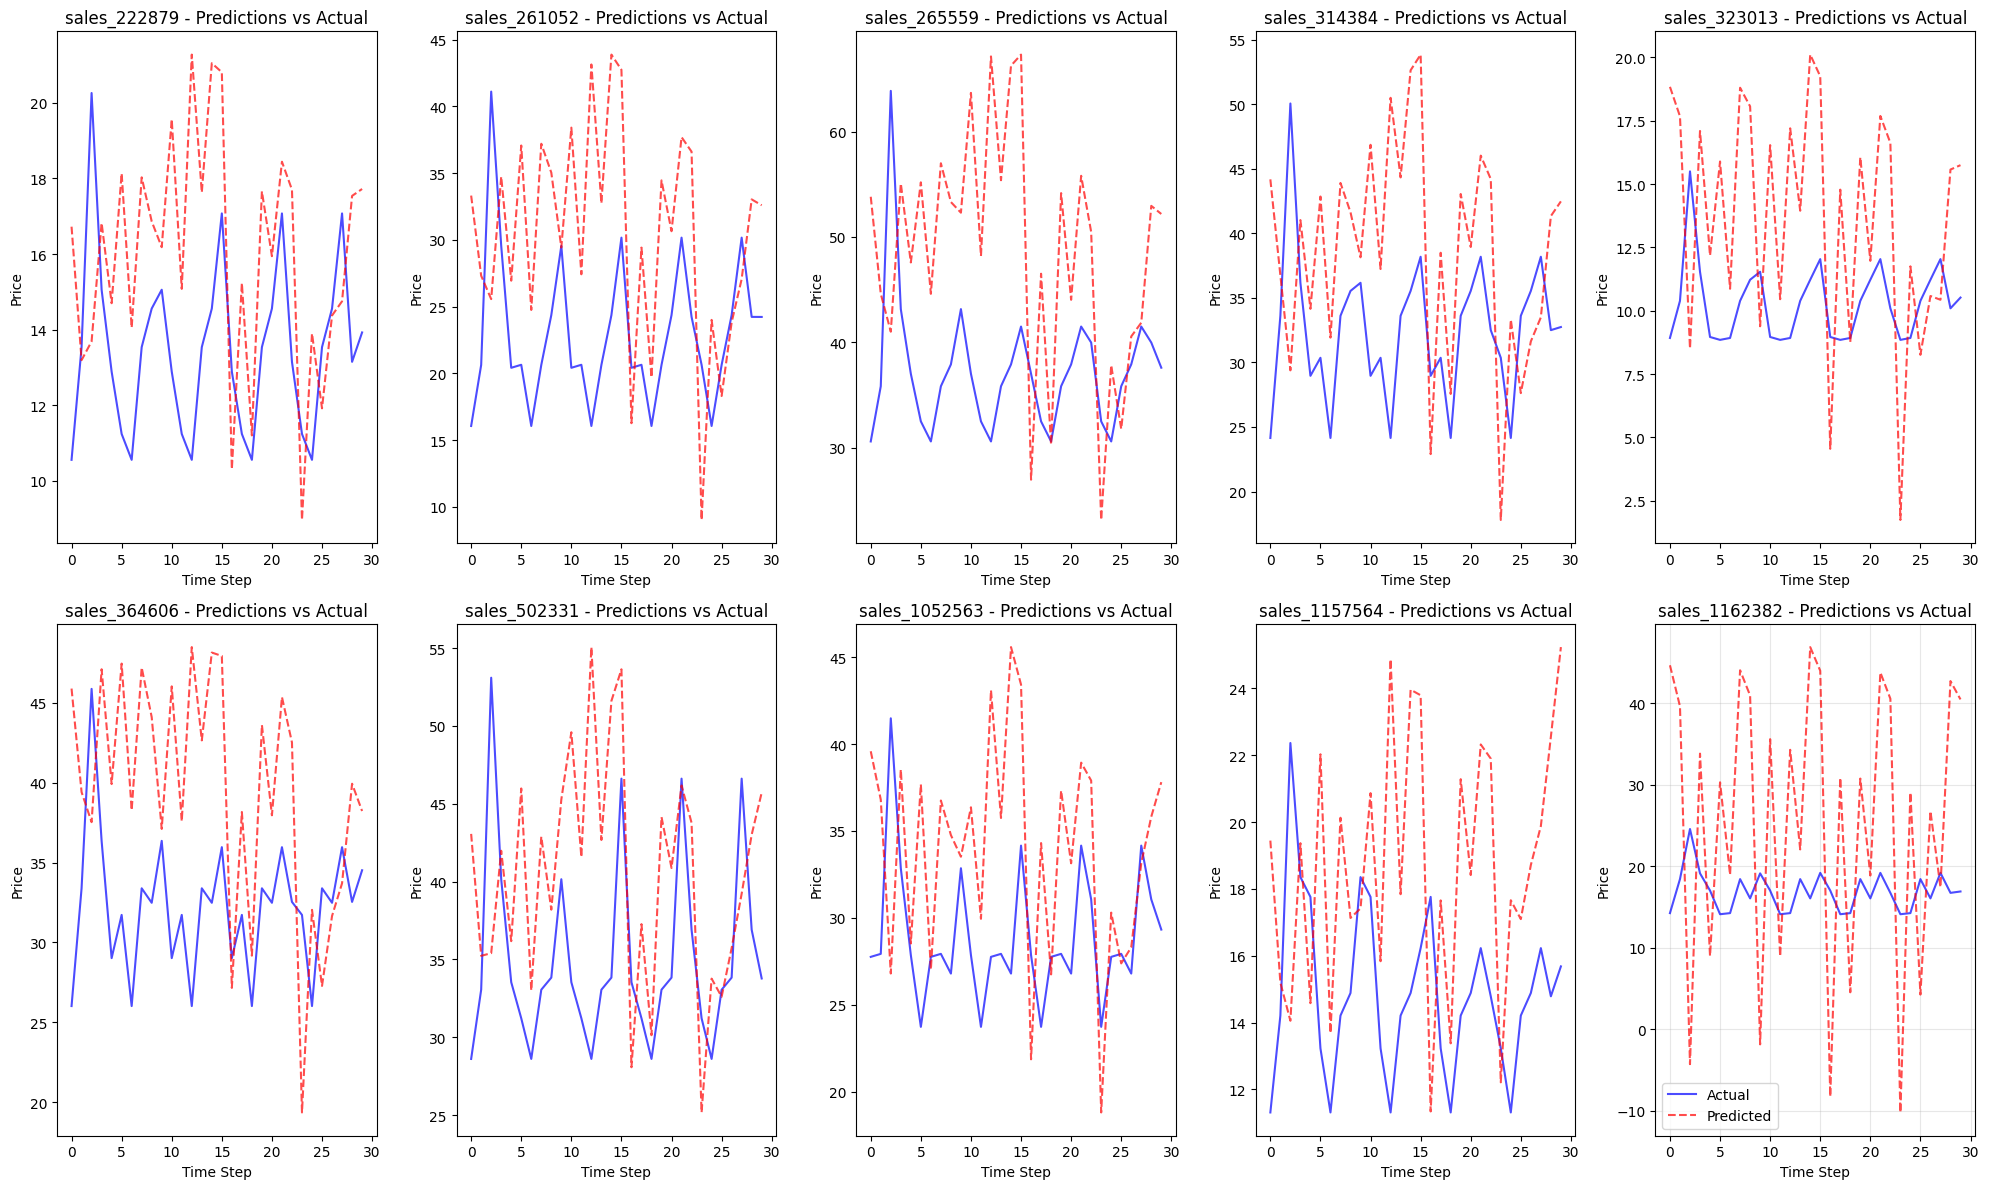


=== Per-Stock Metrics ===
sales_222879: RMSE=4.3627, MAE=3.5672
sales_261052: RMSE=10.7908, MAE=8.9631
sales_265559: RMSE=16.0753, MAE=13.4321
sales_314384: RMSE=10.8380, MAE=8.9842
sales_323013: RMSE=5.8864, MAE=4.9625
sales_364606: RMSE=10.6844, MAE=8.8138
sales_502331: RMSE=10.0181, MAE=8.0612
sales_1052563: RMSE=7.9105, MAE=6.3903
sales_1157564: RMSE=6.5020, MAE=5.4651
sales_1162382: RMSE=19.2881, MAE=16.8018


In [15]:
import matplotlib.pyplot as plt
# Combine all predictions and actuals
all_preds = np.concatenate(predictions, axis=0);
all_actuals = np.concatenate(actuals, axis=0);

# Calculate RMSE and MAE in original scale
rmse = np.sqrt(np.mean((all_preds - all_actuals) ** 2));
mae = np.mean(np.abs(all_preds - all_actuals));

print(f"\n=== Test Results (Original Scale) ===");
print(f"RMSE: {rmse:.4f}");
print(f"MAE: {mae:.4f}");
print(f"Average Price Level: {np.mean(all_actuals):.2f}");
print(f"RMSE as % of Avg Price: {(rmse/np.mean(all_actuals)*100):.2f}%");


# Plot predictions vs actuals for first stock
plt.figure(figsize=(20, 12));
for stock_idx in range(len(stock_cols)):
    plt.subplot(2, 5, stock_idx+1); # Changed to 2x5 grid
    plt.plot(all_actuals[:, stock_idx][-30:], label='Actual', color='blue',alpha=0.7);
    plt.plot(all_preds[:, stock_idx][-30:], label='Predicted', color='red',alpha=0.7, linestyle='--');
    plt.title(f'{stock_cols[stock_idx]} - Predictions vs Actual');
    plt.xlabel('Time Step');
    plt.ylabel('Price');
plt.legend();
plt.grid(True, alpha=0.3);

plt.tight_layout();
plt.show();

# Calculate per-stock metrics
print("\n=== Per-Stock Metrics ===");
for i, stock in enumerate(stock_cols):
    stock_rmse = np.sqrt(np.mean((all_preds[:, i] - all_actuals[:, i]) ** 2));
    stock_mae = np.mean(np.abs(all_preds[:, i] - all_actuals[:, i]));
    print(f"{stock}: RMSE={stock_rmse:.4f}, MAE={stock_mae:.4f}");

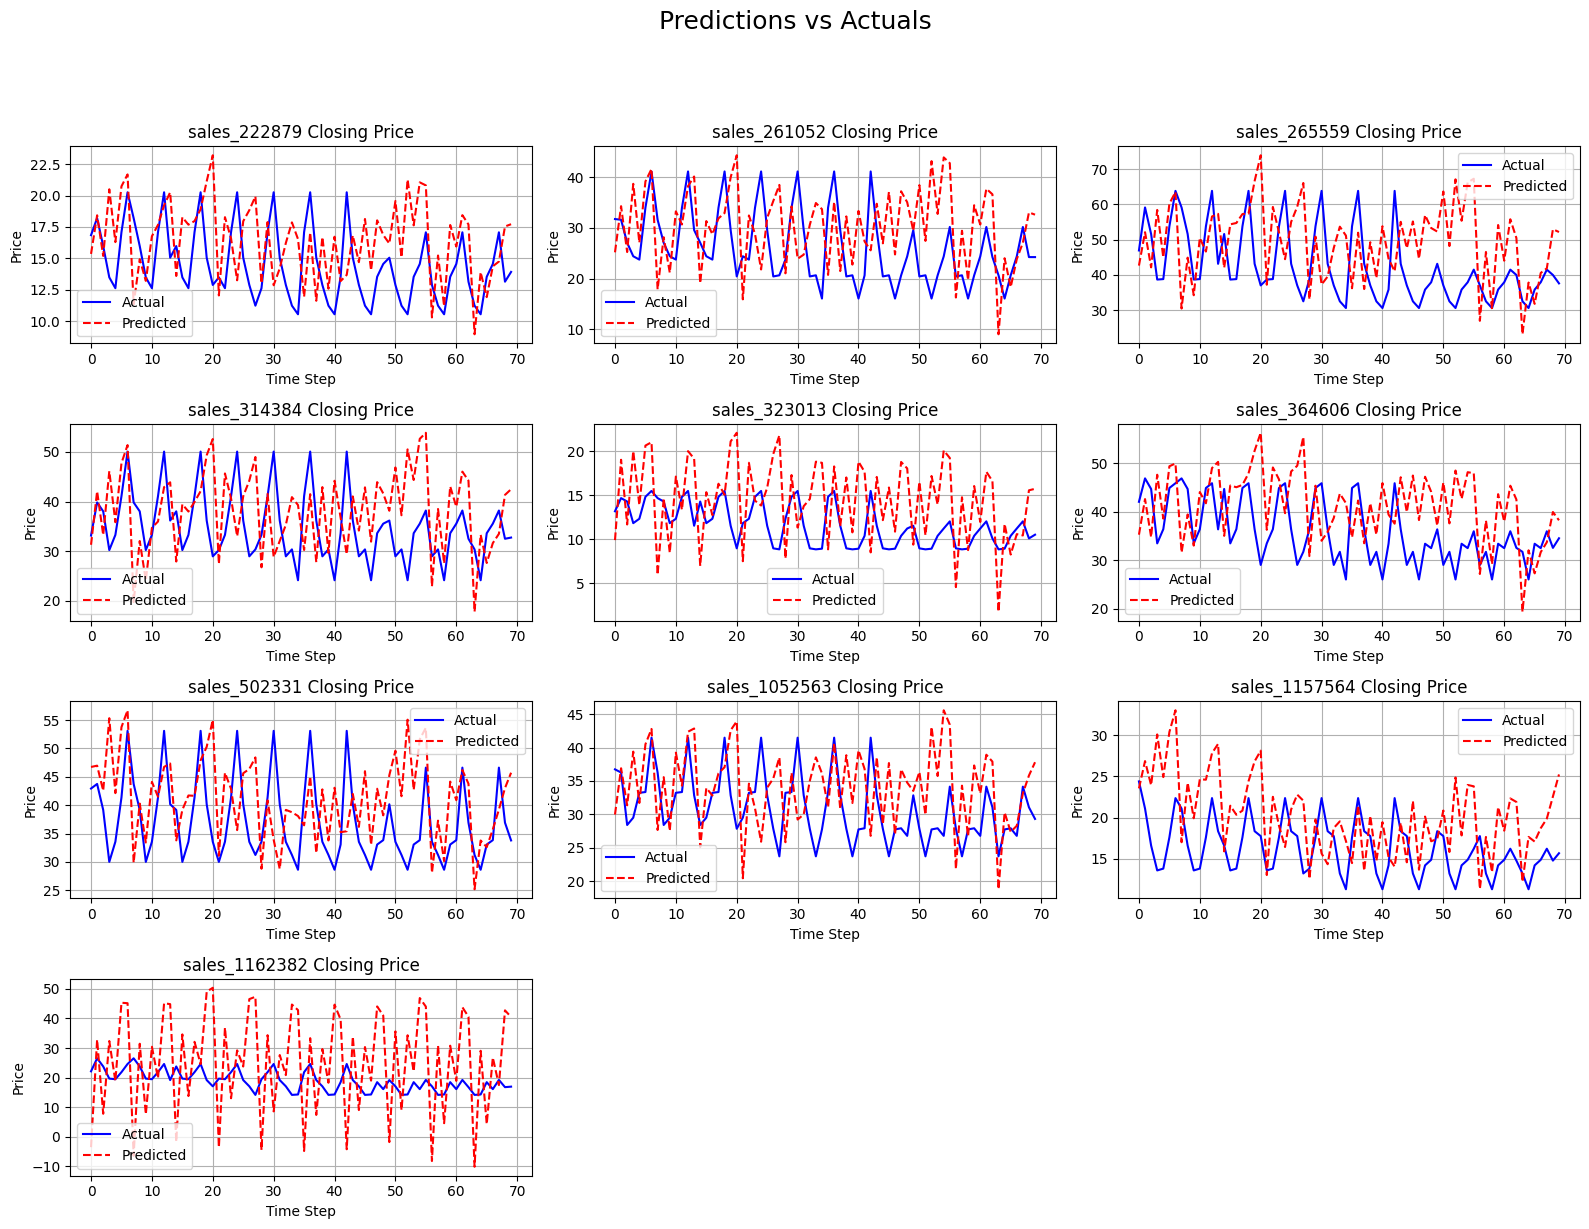


Metrics for sales_222879:
MSE: 19.0335
MAE: 3.5672
RMSE: 4.3627
MAPE: 26.3405%
MSPE: 19.033523559570312
sqrt MSPE: 4.362742900848389
R2: -1.4221

Metrics for sales_261052:
MSE: 116.4407
MAE: 8.9631
RMSE: 10.7908
MAPE: 38.5094%
MSPE: 116.44073486328125
sqrt MSPE: 10.790770530700684
R2: -1.3783

Metrics for sales_265559:
MSE: 258.4142
MAE: 13.4321
RMSE: 16.0753
MAPE: 34.1060%
MSPE: 258.41424560546875
sqrt MSPE: 16.075267791748047
R2: -1.5761

Metrics for sales_314384:
MSE: 117.4632
MAE: 8.9842
RMSE: 10.8380
MAPE: 27.2674%
MSPE: 117.46324157714844
sqrt MSPE: 10.838046073913574
R2: -1.5921

Metrics for sales_323013:
MSE: 34.6496
MAE: 4.9625
RMSE: 5.8864
MAPE: 46.3040%
MSPE: 34.64964294433594
sqrt MSPE: 5.886394500732422
R2: -5.4822

Metrics for sales_364606:
MSE: 114.1559
MAE: 8.8138
RMSE: 10.6844
MAPE: 26.5811%
MSPE: 114.15589141845703
sqrt MSPE: 10.684375762939453
R2: -1.7948

Metrics for sales_502331:
MSE: 100.3628
MAE: 8.0612
RMSE: 10.0181
MAPE: 22.6726%
MSPE: 100.36283111572266
sqrt 

In [16]:
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score
import numpy as np
from sklearn import metrics

# Use variables from the previous execution
# all_preds and all_actuals are already in the original scale (inverse transformed)
inversed_predictions = all_preds
inversed_actuals = all_actuals

plt.figure(figsize=(16, 12))
plt.suptitle('Predictions vs Actuals', fontsize=18, y=1.02)  # main title

# Adjust subplot layout based on number of stocks
n_cols = 3
n_rows = (len(stock_cols) + n_cols - 1) // n_cols

for i, col in enumerate(stock_cols):
    plt.subplot(n_rows, n_cols, i+1)
    plt.plot(inversed_actuals[:, i], label='Actual', color='blue')
    plt.plot(inversed_predictions[:, i], label='Predicted', color='red', linestyle='--')
    plt.title(f'{col} Closing Price')
    plt.xlabel('Time Step')
    plt.ylabel('Price')
    plt.legend()
    plt.grid(True)

plt.tight_layout(rect=[0, 0, 1, 0.97])  # leave room for suptitle
plt.show()

def mean_absolute_percentage_error(y_test, y_pred):
    y_true, y_pred = np.array(y_test), np.array(y_pred)
    # Avoid division by zero
    mask = y_true != 0
    if np.sum(mask) == 0: return np.nan
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

def mean_squared_prediction_error(y_test, y_pred):
    y_true, y_pred = np.array(y_test), np.array(y_pred)
    return np.mean(((y_true - y_pred))**2)

for i, col in enumerate(stock_cols):
    print(f"\nMetrics for {col}:")
    print(f'MSE: {metrics.mean_squared_error(inversed_actuals[:, i], inversed_predictions[:, i]):.4f}')
    print(f'MAE: {metrics.mean_absolute_error(inversed_actuals[:, i], inversed_predictions[:, i]):.4f}')
    print(f'RMSE: {np.sqrt(metrics.mean_squared_error(inversed_actuals[:, i], inversed_predictions[:, i])):.4f}')
    print(f'MAPE: {mean_absolute_percentage_error(inversed_actuals[:, i], inversed_predictions[:, i]):.4f}%')
    print(f'MSPE: {mean_squared_prediction_error(all_actuals[:, i], all_preds[:, i])}')
    print(f'sqrt MSPE: {np.sqrt(mean_squared_prediction_error(all_actuals[:, i], all_preds[:, i]))}')
    print(f'R2: {r2_score(inversed_actuals[:, i], inversed_predictions[:, i]):.4f}')

# Overall metrics (using only the stock columns)
print("\nOverall Metrics (Stocks only):")
# Filter only stock columns for overall metrics (first len(stock_cols) columns)
stock_actuals = inversed_actuals[:, :len(stock_cols)]
stock_preds = inversed_predictions[:, :len(stock_cols)]

print(f'MSE: {metrics.mean_squared_error(inversed_actuals, inversed_predictions):.4f}')
print(f'MAE: {metrics.mean_absolute_error(inversed_actuals, inversed_predictions):.4f}')
print(f'RMSE: {np.sqrt(metrics.mean_squared_error(inversed_actuals, inversed_predictions)):.4f}')
print(f'MAPE: {mean_absolute_percentage_error(inversed_actuals, inversed_predictions):.4f}%')
print(f'MSPE: {mean_squared_prediction_error(inversed_actuals, inversed_predictions)}')
print(f'sqrt MSPE: {np.sqrt(mean_squared_prediction_error(inversed_actuals, inversed_predictions))}')
print(f'R2: {r2_score(inversed_actuals, inversed_predictions):.4f}')

In [17]:
for i, col in enumerate(stock_cols):
    y_true = all_actuals[:, i]
    y_pred = all_preds[:, i]

    print(f"{col}")
    print("MSE:", metrics.mean_squared_error(y_true, y_pred))
    print("RMSE:", np.sqrt(metrics.mean_squared_error(y_true, y_pred)))
    print("MAE:", metrics.mean_absolute_error(y_true, y_pred))
    print("MAPE:", mean_absolute_percentage_error(y_true, y_pred))
    print("R2:", r2_score(y_true, y_pred))


print("\nOverall Metrics (Stocks only):")
print(f'MSE: {metrics.mean_squared_error(y_true, y_pred):.4f}')
print(f'MAE: {metrics.mean_absolute_error(y_true, y_pred):.4f}')
print(f'RMSE: {np.sqrt(metrics.mean_squared_error(y_true, y_pred)):.4f}')
print(f'MAPE: {mean_absolute_percentage_error(y_true, y_pred):.4f}%')
print(f'MSPE: {mean_squared_prediction_error(y_true, y_pred)}')
print(f'sqrt MSPE: {np.sqrt(mean_squared_prediction_error(y_true, y_pred))}')
print(f'R2: {r2_score(y_true, y_pred):.4f}')

sales_222879
MSE: 19.033523559570312
RMSE: 4.362742664834853
MAE: 3.5671801567077637
MAPE: 26.340464
R2: -1.4221465587615967
sales_261052
MSE: 116.44073486328125
RMSE: 10.790770818772923
MAE: 8.96310806274414
MAPE: 38.50942
R2: -1.3782870769500732
sales_265559
MSE: 258.41424560546875
RMSE: 16.0752681347923
MAE: 13.432069778442383
MAPE: 34.10599
R2: -1.5760509967803955
sales_314384
MSE: 117.46324157714844
RMSE: 10.838046022099576
MAE: 8.984224319458008
MAPE: 27.267433
R2: -1.592108964920044
sales_323013
MSE: 34.64964294433594
RMSE: 5.8863947322903805
MAE: 4.962457180023193
MAPE: 46.304005
R2: -5.482159614562988
sales_364606
MSE: 114.15589141845703
RMSE: 10.684376042542542
MAE: 8.813760757446289
MAPE: 26.581087
R2: -1.7948286533355713
sales_502331
MSE: 100.36283111572266
RMSE: 10.018125129769674
MAE: 8.061205863952637
MAPE: 22.67263
R2: -0.9897071123123169
sales_1052563
MSE: 62.57596969604492
RMSE: 7.910497436700483
MAE: 6.390260219573975
MAPE: 21.778236
R2: -1.6993610858917236
sales_115

In [18]:
def numpy_normalised_quantile_loss(y, y_pred, quantile):
  """Computes normalised quantile loss for numpy arrays.

  Uses the q-Risk metric as defined in the "Training Procedure" section of the
  main TFT paper.

  Args:
    y: Targets
    y_pred: Predictions
    quantile: Quantile to use for loss calculations (between 0 & 1)

  Returns:
    Float for normalised quantile loss.
  """
  prediction_underflow = y - y_pred
  weighted_errors = quantile * np.maximum(prediction_underflow, 0.) \
      + (1. - quantile) * np.maximum(-prediction_underflow, 0.)

  quantile_loss = weighted_errors.mean()
  normaliser = np.abs(y).mean() # Corrected line: use np.abs for numpy arrays

  return 2 * quantile_loss / normaliser

q_risk = numpy_normalised_quantile_loss(inversed_actuals, inversed_predictions,0.9)
print(q_risk)

0.17080645
